# 04 - Stage 2 RL Fine-tuning (Colab A100)
PPO-based reinforcement learning on top of the Stage 1 pre-trained REACT model.

## Setup Instructions
Before running this notebook:
1. Stage 1 must be complete — `checkpoint_best.pt` must exist at `MyDrive/CiteMind/checkpoints/pretrain/`
2. `data.zip` must still be in `MyDrive/CiteMind/` (same as Stage 1)
3. Set runtime to **A100 GPU**: Runtime → Change runtime type → A100 GPU
4. Run all cells in order

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR   = '/content/drive/MyDrive/CiteMind'
DATA_ZIP    = f'{DRIVE_DIR}/data.zip'
PRETRAIN_CKPT_DIR = f'{DRIVE_DIR}/checkpoints/pretrain'
RL_CKPT_DIR = f'{DRIVE_DIR}/checkpoints/rl'

import os
os.makedirs(RL_CKPT_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Stage 1 checkpoint dir : {PRETRAIN_CKPT_DIR}')
print(f'Stage 2 checkpoint dir : {RL_CKPT_DIR}')

Mounted at /content/drive
Drive mounted.
Stage 1 checkpoint dir : /content/drive/MyDrive/CiteMind/checkpoints/pretrain
Stage 2 checkpoint dir : /content/drive/MyDrive/CiteMind/checkpoints/rl


In [2]:
# ── Step 2: Clone / pull repo ────────────────────────────────────────────
import os
if not os.path.exists('/content/repo'):
    !git clone https://github.com/mohamedzait20003/ECE595NLP-Project /content/repo
else:
    !git -C /content/repo pull origin main
%cd /content/repo
print('Repo ready.')

Cloning into '/content/repo'...
remote: Enumerating objects: 423, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 423 (delta 75), reused 69 (delta 38), pack-reused 297 (from 1)
Receiving objects: 100% (423/423), 7.61 MiB | 20.30 MiB/s, done.
Resolving deltas: 100% (267/267), done.
/content/repo
Repo ready.


In [3]:
# ── Step 3: Install dependencies ─────────────────────────────────────────
!apt-get install -q libsndfile1
!pip install -q -r requirements.txt
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
!pip install -q sentence-transformers
print('Dependencies installed.')

Reading package lists...
Building dependency tree...
Reading state information...
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Dependencies installed.


In [4]:
# ── Step 4: Extract data ─────────────────────────────────────────────────
import os, json, re
from pathlib import Path

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError(
        f'Data zip not found at {DATA_ZIP}\n'
        'Please upload data.zip to MyDrive/CiteMind/ in Google Drive.'
    )

print(f'Found: {DATA_ZIP}')
!unzip -q -o "{DATA_ZIP}" -d /content/repo/src/data
print('Zip extracted.')

# Patch Windows absolute paths in manifest JSON files → Colab paths
AUDIO_BASE = '/content/repo/src/data/audio'
target = Path('/content/repo/src/data')

for manifest_name in ['train_manifest.json', 'val_manifest.json', 'test_manifest.json']:
    manifest_path = target / 'audio' / manifest_name
    if not manifest_path.exists():
        continue
    with open(manifest_path, 'r', encoding='utf-8') as f:
        entries = json.load(f)
    patched = 0
    for entry in entries:
        ap = entry.get('audio_path', '')
        if not ap.startswith('/content'):
            parts = re.split(r'[/\\]', ap)
            fname  = parts[-1]
            subdir = parts[-2] if len(parts) >= 2 else manifest_name.split('_')[0]
            entry['audio_path'] = f'{AUDIO_BASE}/{subdir}/{fname}'
            patched += 1
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(entries, f)
    print(f'  Patched {patched} paths in {manifest_name}')

# Verify
print()
for f in ['src/data/audio/train_manifest.json',
          'src/data/audio/val_manifest.json',
          'src/data/processed/train.json']:
    status = 'OK' if os.path.exists(f'/content/repo/{f}') else 'MISSING'
    print(f'  [{status}]  {f}')

Found: /content/drive/MyDrive/CiteMind/data.zip
Zip extracted.
  Patched 63971 paths in train_manifest.json
  Patched 7996 paths in val_manifest.json
  Patched 7997 paths in test_manifest.json

  [OK]  src/data/audio/train_manifest.json
  [OK]  src/data/audio/val_manifest.json
  [OK]  src/data/processed/train.json


In [5]:
# ── Step 5: Verify GPU & Stage 1 checkpoint ──────────────────────────────
import sys, torch
sys.path.insert(0, '/content/repo')

assert torch.cuda.is_available(), 'No GPU found! Set runtime to A100.'
print(f'Device : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

import os
stage1_ckpt = f'{PRETRAIN_CKPT_DIR}/checkpoint_best.pt'
assert os.path.exists(stage1_ckpt), f'Stage 1 checkpoint not found: {stage1_ckpt}'
print(f'Stage 1 checkpoint : OK  ({stage1_ckpt})')

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
Stage 1 checkpoint : OK  (/content/drive/MyDrive/CiteMind/checkpoints/pretrain/checkpoint_best.pt)


In [6]:
# ── Step 6: Set checkpoint directories ──────────────────────────────────
import yaml
from pathlib import Path

config_path = Path('/content/repo/src/config/rl_config.yaml')

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Only set Drive-specific paths — all other settings come from the YAML
config['rl']['stage1_checkpoint']    = stage1_ckpt
config['training']['checkpoint_dir'] = RL_CKPT_DIR

with open(config_path, 'w') as f:
    yaml.dump(config, f)

print('Config loaded from YAML:')
print(f"  stage1_checkpoint : {config['rl']['stage1_checkpoint']}")
print(f"  total_steps       : {config['training']['total_steps']}")
print(f"  batch_size        : {config['training']['batch_size']}")
print(f"  warmup_steps      : {config['training']['warmup_steps']}")
print(f"  learning_rate     : {config['training']['learning_rate']}")
print(f"  fp16              : {config['training']['fp16']}")
print(f"  kl_coef           : {config['rl']['kl_coef']}")
print(f"  ppo_epochs        : {config['rl']['ppo_epochs']}")
print(f"  num_workers       : {config['data']['num_workers']}")
print(f"  reward weights    : {config['rl']['reward_weights']}")
print(f"  checkpoint_dir    : {config['training']['checkpoint_dir']}")

Config loaded from YAML:
  stage1_checkpoint : /content/drive/MyDrive/CiteMind/checkpoints/pretrain/checkpoint_best.pt
  total_steps       : 1500
  batch_size        : 8
  warmup_steps      : 100
  learning_rate     : 5e-07
  fp16              : True
  kl_coef           : 3.0
  ppo_epochs        : 1
  num_workers       : 4
  reward weights    : {'retrieval': 0.3, 'nli': 0.3, 'hallucination': 0.2, 'exact_match': 0.5}
  checkpoint_dir    : /content/drive/MyDrive/CiteMind/checkpoints/rl


In [7]:
# ── Step 7: Run RL training ──────────────────────────────────────────────
from src.main.training.rl_train import rl_train
rl_train(str(config_path))

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

  Step   1475 | reward: 0.2200 | kl: -0.7768 | pg: 0.0230 | vf: 3.5457


RL fine-tuning: 100%|██████████| 1500/1500 [21:48<00:00,  1.25it/s, kl=-1.4797, pg=0.0000, reward=0.0991, vf=0.0000]

  Step   1500 | reward: 0.0991 | kl: -1.4797 | pg: 0.0000 | vf: 0.0000


RL fine-tuning: 100%|██████████| 1500/1500 [21:51<00:00,  1.14it/s, kl=-1.4797, pg=0.0000, reward=0.0991, vf=0.0000]


RL training complete. Best reward: 0.1594
Checkpoints saved to: /content/drive/MyDrive/CiteMind/checkpoints/rl


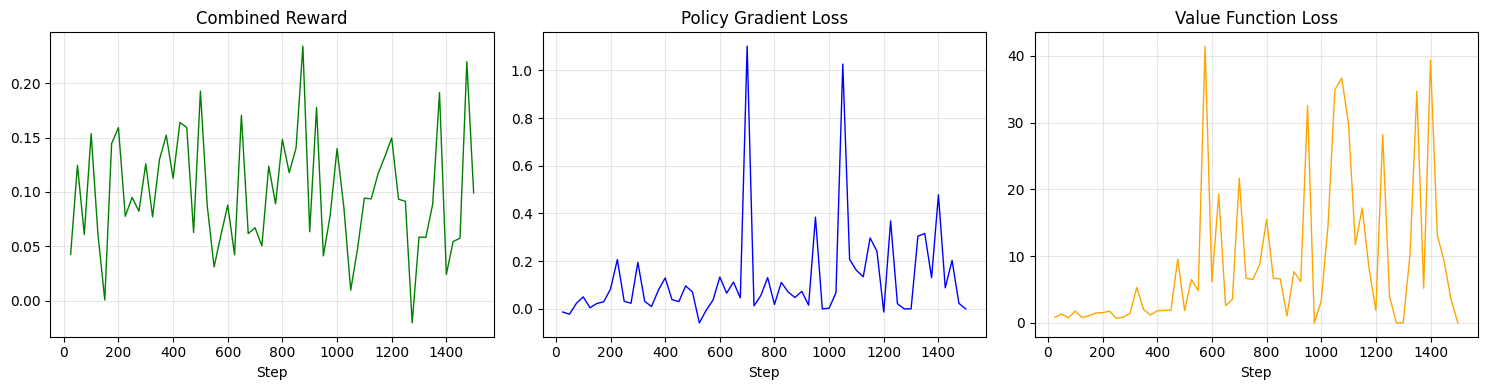

Final reward : 0.0991
Best  reward : 0.2344


In [8]:
# ── Step 8: Plot RL reward curve ─────────────────────────────────────────
import json
import matplotlib.pyplot as plt
from pathlib import Path

log_path = Path(RL_CKPT_DIR) / 'rl_log.json'

with open(log_path, 'r') as f:
    history = json.load(f)

steps   = [h['step']   for h in history]
rewards = [h['reward'] for h in history]
pg_loss = [h['pg_loss'] for h in history]
vf_loss = [h['vf_loss'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, rewards, linewidth=1, color='green')
axes[0].set_title('Combined Reward')
axes[0].set_xlabel('Step')
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, pg_loss, linewidth=1, color='blue')
axes[1].set_title('Policy Gradient Loss')
axes[1].set_xlabel('Step')
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, vf_loss, linewidth=1, color='orange')
axes[2].set_title('Value Function Loss')
axes[2].set_xlabel('Step')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final reward : {rewards[-1]:.4f}')
print(f'Best  reward : {max(rewards):.4f}')

In [9]:
# ── Step 9: Sanity check on best RL checkpoint ───────────────────────────
import json
import torch
import librosa
from pathlib import Path
from src.main.model.main_model import MainModel
from transformers import BartTokenizer, WhisperProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = Path(RL_CKPT_DIR) / 'checkpoint_best_rl.pt'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f'Best RL checkpoint — step: {ckpt["step"]} | best_reward: {ckpt["best_reward"]:.4f}')

model = MainModel(
    whispher_model='openai/whisper-small',
    bart_model='facebook/bart-base'
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')
processor = WhisperProcessor.from_pretrained('openai/whisper-small')

# Load real test samples
with open('/content/repo/src/data/audio/test_manifest.json', 'r') as f:
    test_entries = json.load(f)

for i in range(min(5, len(test_entries))):
    sample = test_entries[i]
    print(f'\n--- Sample {i+1} ---')
    print(f'Source   : {sample["source_title"][:80]}')
    print(f'Expected : {sample["citation_string"]}')

    waveform, sr = librosa.load(sample['audio_path'], sr=16000)
    audio_features = processor(
        waveform, sampling_rate=16000, return_tensors='pt'
    ).input_features.to(device)

    ctx = f"{sample['source_title']} </s> {sample['source_abstract']}"
    enc = tokenizer(ctx, return_tensors='pt', max_length=512, truncation=True)
    text_ids  = enc['input_ids'].to(device)
    text_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        out = model.generate(
            audio_features=audio_features,
            text_input_ids=text_ids,
            text_attention_mask=text_mask,
            max_length=64,
        )

    print(f'Generated: {tokenizer.decode(out[0], skip_special_tokens=True)}')

print(f'\nRL Checkpoints saved to Google Drive at: {RL_CKPT_DIR}')


Best RL checkpoint — step: 450 | best_reward: 0.1594


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


--- Sample 1 ---
Source   : Context-aware LLM-based Safe Control Against Latent Risks
Expected : Zarzà et al., 2023
Generated: Zui et al., 2024

--- Sample 2 ---
Source   : Mucha: Multi-channel based Code Change Representation Learning for Commit Messag
Expected : Cvitkovic et al., 2018
Generated: Lang et al., 2022

--- Sample 3 ---
Source   : Q-Bridge: Code Translation for Quantum Machine Learning via LLMs
Expected : Agarwal et al., 2025
Generated: Lang et al., 2022

--- Sample 4 ---
Source   : Investigating Compositional Reasoning in Time Series Foundation Models
Expected : Yang et al., 2024
Generated: Zui et al., 2024

--- Sample 5 ---
Source   : Maintaining Image Size by Developing the Cropping Rectangle Method on CT-Scan Im
Expected : Mosel et al., 2021
Generated: Liu et al., 2022

RL Checkpoints saved to Google Drive at: /content/drive/MyDrive/CiteMind/checkpoints/rl
